In [1]:
import os
import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"


In [3]:
def topological_sort(graph):
    visited = set()
    stack = []

    def dfs(node):
        visited.add(node)
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                dfs(neighbor)
        stack.append(node)

    for node in graph:
        if node not in visited:
            dfs(node)

    return stack[::-1]  # Reverse the stack to get the topological order


In [4]:
def rename_sample(name: str) -> str:
    if name == "SUB2h1":
        name = "SUB2k"
    elif name == "SUB2h2":
        name = "SUB2h"
    elif name == "SUB7a1":
        name = "SUB7a"
    elif name == "SUB7a2":
        name = "SUB6a"
    elif name == "SUB18a1":
        name = "SUB18a"
    elif name == "SUB18a2":
        name = "SUB19a"
    elif name.startswith("yqebmeta"):
        name = name.replace("yqebmeta", "SUB")
    
    name = name.replace("SUB", "")
    # append 0 if name is a single digit
    name = name.zfill(3).upper()
    return name


In [5]:
def parse_bracken_reports(
    directory_path: str, pattern: str = "_kraken_report_bracken_species.txt"
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Parse multiple Bracken report files into abundance, read count, and taxonomy DataFrames.

    Args:
        directory_path: Path to the directory containing Bracken report files.
        pattern: Pattern to identify Bracken report files.

    Returns:
        Tuple of:
        - abundance_df: DataFrame with samples as rows and taxa as columns (percentage abundance).
        - read_count_df: DataFrame with samples as rows and taxa as columns (read counts).
        - tax_df: DataFrame with one row per taxon and columns representing original Bracken levels (e.g., F, G, G1).
    """
    file_paths = glob.glob(os.path.join(directory_path, f"*{pattern}"))

    all_data: dict[str, dict[str, float]] = {}
    all_reads: dict[str, dict[str, int]] = {}
    taxonomy_records: dict[str, dict[str, str | None]] = {}
    dups = defaultdict(int)

    graph = defaultdict(list)

    for file_path in file_paths:
        filename = os.path.basename(file_path)
        sample_name = filename.split("_")[0]

        df = pd.read_table(
            file_path,
            header=None,
            names=["percentage", "reads", "reads_direct", "level", "taxid", "name"],
            dtype={"name": str},
        )

        # Normalize name and compute indentation
        df["indent"] = df["name"].str.extract(r"^(\s*)")[0].str.len()
        df["name"] = df["name"].str.lstrip()

        # Track order of level codes as they appear
        # for level_code in df["level"]:
        #     if level_code not in observed_levels:
        #         observed_levels.append(level_code)

        sample_abund: dict[str, float] = {}
        sample_reads: dict[str, int] = {}

        # [indent, taxon_name, level_code]
        lineage_stack: list[tuple[int, str, str]] = []
        # current_lineage: dict[str, str | None] = {}

        for _, row in df.iterrows():
            taxon_name = row["name"]
            level_code = row["level"]
            indent = row["indent"]

            # Pop from stack if indent decreases
            while lineage_stack and lineage_stack[-1][0] >= indent:
                lineage_stack.pop()
            if lineage_stack:
                src = lineage_stack[-1][2]
                graph[src].append(level_code)

            # Build current lineage from stack
            # current_lineage = {lvl: None for lvl in levels}
            current_lineage = {}
            for _, ancestor_name, ancestor_level in lineage_stack:
                current_lineage[ancestor_level] = ancestor_name

            # Add the current taxon
            current_lineage[level_code] = taxon_name
            lineage_stack.append((indent, taxon_name, level_code))
            if taxon_name not in taxonomy_records:
                taxonomy_records[taxon_name] = current_lineage.copy()
            else:
                if taxonomy_records[taxon_name] != current_lineage:
                    print(f"Duplicate taxon name: {taxon_name}")
                    dups[taxon_name] += 1
                    taxon_name = taxon_name + f".{dups[taxon_name]}"
                    taxonomy_records[taxon_name] = current_lineage.copy()
                # otherwise do nothing

            sample_abund[taxon_name] = row["percentage"]
            sample_reads[taxon_name] = row["reads"]

        all_data[sample_name] = sample_abund
        all_reads[sample_name] = sample_reads

    abundance_df = pd.DataFrame.from_dict(all_data, orient="index").fillna(0)
    read_count_df = pd.DataFrame.from_dict(all_reads, orient="index").fillna(0)
    cols = topological_sort(graph)
    tax_df = pd.DataFrame.from_dict(taxonomy_records, orient="index", columns=cols)

    return abundance_df, read_count_df, tax_df

In [6]:
abundance_df, read_count_df, tax_df = parse_bracken_reports("./kraken_with_host")
index = abundance_df.index
index_new = index.map(rename_sample)
abundance_df.index= abundance_df.index.map(rename_sample)
read_count_df.index = read_count_df.index.map(rename_sample)
abundance_df = abundance_df.sort_index()
read_count_df = read_count_df.sort_index()

Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples


In [7]:
# pd.DataFrame(dict(sample=index_new), index=index).to_csv("metadata.csv")

In [8]:
tax2level = {
    idx: tax_df.columns[np.where(~row.isnull())[0].max()]
    for idx, row in tax_df.iterrows()
}
abundance_df_s = abundance_df[[t for t in abundance_df.columns if tax2level[t] == "S"]]
abundance_df_d = abundance_df[[t for t in abundance_df.columns if tax2level[t] == "D"]]
read_count_df_s = read_count_df[
    [t for t in abundance_df.columns if tax2level[t] == "S"]
].astype(int)
read_count_df_d = read_count_df[
    [t for t in abundance_df.columns if tax2level[t] == "D"]
].astype(int)

abundance_df_s_bac = abundance_df_s[
    [t for t in abundance_df_s.columns if tax_df.loc[t, "D"] == "Bacteria"]
]
abundance_df_s_bac = abundance_df_s_bac.div(abundance_df_s_bac.sum(axis=1), axis=0)
read_count_df_s_bac = read_count_df[
    [
        t
        for t in abundance_df_s.columns
        if tax_df.loc[t, "D"] == "Bacteria" and tax2level[t] == "S"
    ]
].astype(int)

In [9]:
read_count_df_s_bac.to_csv("read_count_species_bac.csv")
read_count_df_s.to_csv("read_count_species_all.csv")

/tmp/ipykernel_375491/3521288805.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0, 0.5, 'Bacterial Read Count (log scale)')

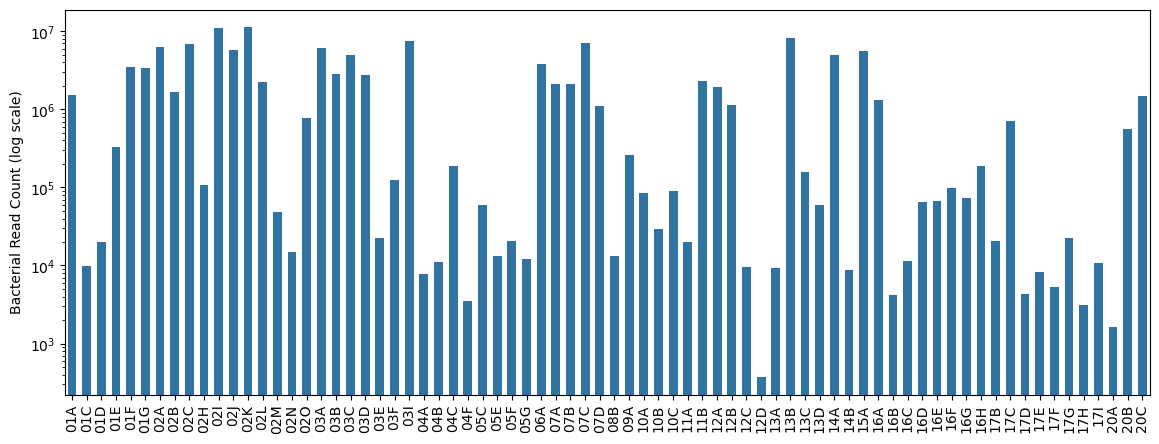

In [10]:
fig, ax= plt.subplots(figsize=(14, 5))
# read_count_df_s_bac.sum(axis=1).plot(kind="bar", logy=True, ax=ax)
sns.barplot(
    data=read_count_df_s_bac.sum(axis=1),
    ax=ax,
    width=0.6,
    # log_scale=(False, True),
    # ci=None,
)
ax.set_yscale("log")
# rotate x-axis labels by 90 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel("Bacterial Read Count (log scale)")
# a horizontal line at 1e5
# ax.axhline(2e3, color="red", linestyle="--")

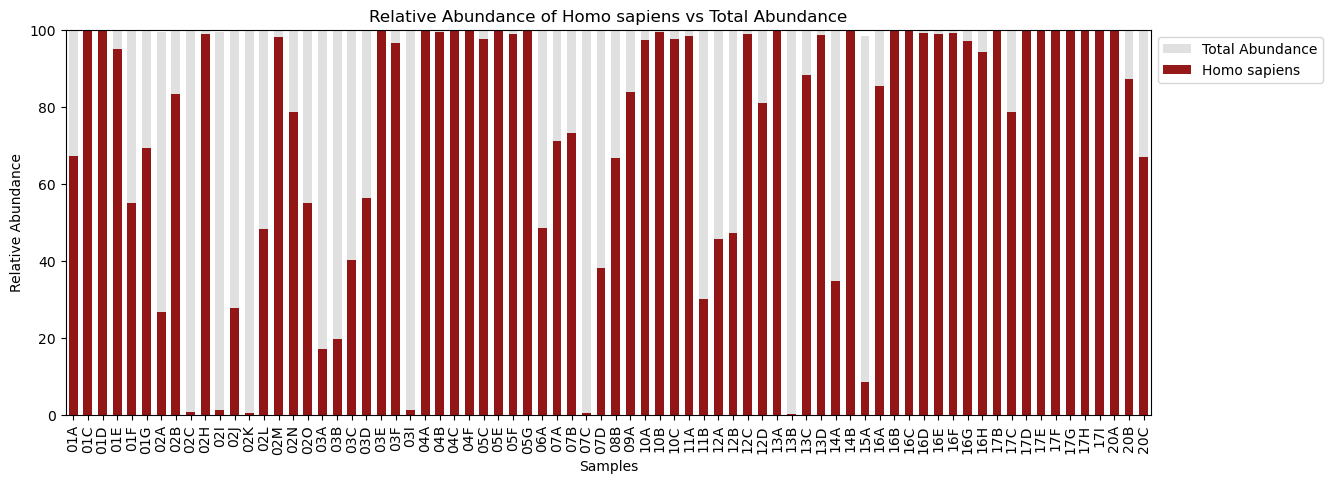

In [11]:
# plot bar plot where each x is a sample and there are two overlapping bars, the front 
# one is rel ab of Homo sapiens and the back one is total rel ab (abundance_df_s.sum(axis=1))
if 'Homo sapiens' in abundance_df_s.columns:
    homo_sapiens_ab = abundance_df_s['Homo sapiens']
else:
    homo_sapiens_ab = pd.Series(0, index=abundance_df_s.index)  # Default to zeros if not present

# Get the total abundance for each sample
total_ab = abundance_df_s.sum(axis=1)

# Set up the x positions for the bars
x = np.arange(len(abundance_df_s.index))
width = 0.6  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the total abundance as the back bars
total_bars = ax.bar(x, total_ab, width, label='Total Abundance', alpha=0.7, color='lightgray')

# Plot Homo sapiens abundance as the front bars
homo_bars = ax.bar(x, homo_sapiens_ab, width, label='Homo sapiens', alpha=0.9, color='darkred')

# Add labels, title and legend
ax.set_xlabel('Samples')
ax.set_ylabel('Relative Abundance')
ax.set_title('Relative Abundance of Homo sapiens vs Total Abundance')
ax.set_xticks(x)
ax.set_ylim(0, 100)  # Set y-axis limit to 100%
ax.set_xlim(-0.5, len(total_ab) - 0.5)  # Adjust x-axis limits
ax.set_xticklabels(abundance_df_s.index, rotation=90)
ax.legend()

# # Add percentage labels for Homo sapiens
# for i, (hs, tot) in enumerate(zip(homo_sapiens_ab, total_ab)):
#     if tot > 0:
#         percentage = (hs / tot) * 100
#         if percentage > 1:  # Only show percentages > 1% to avoid clutter
#             ax.text(i, hs, f'{percentage:.1f}%', ha='center', va='bottom')
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))


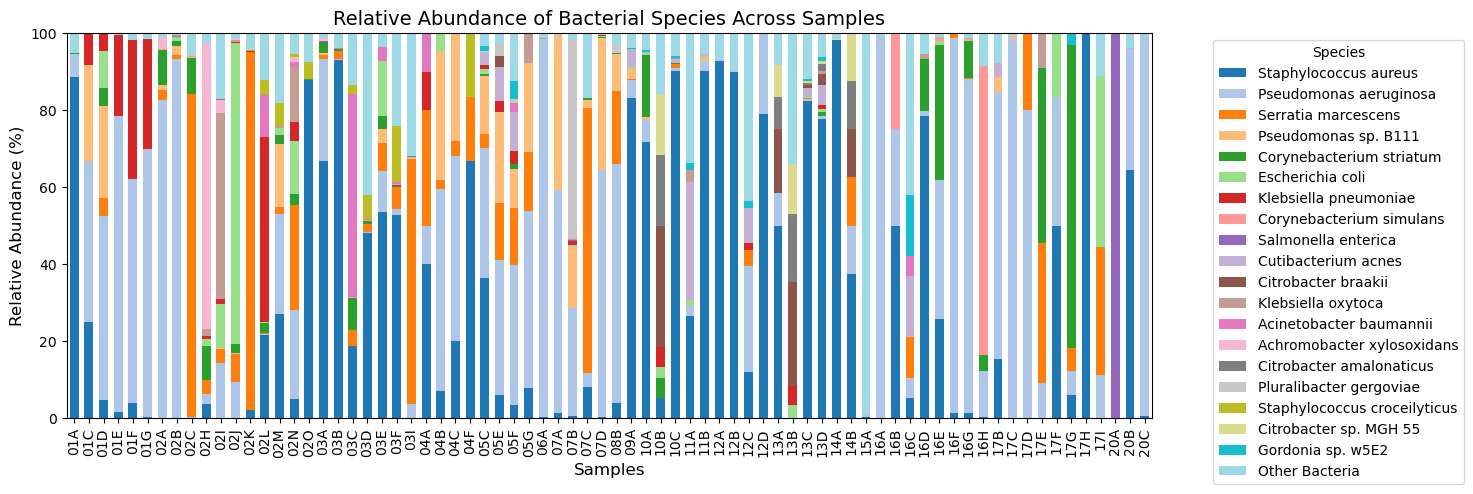

In [12]:
# Create a stacked bar plot for bacterial species abundance (abundance_df_s_bac)
fig, ax = plt.subplots(figsize=(14, 5))

# Getting the top bacteria species for better visualization and legend readability
# Select top N species by mean abundance across samples
n_top_species = 19  # Adjust this number as needed
top_species = (
    abundance_df_s_bac.mean()
    .sort_values(ascending=False)
    .head(n_top_species)
    .index.tolist()
)
other_species = [col for col in abundance_df_s_bac.columns if col not in top_species]

# Create a modified dataframe with top species and an "Other" category
plot_df = abundance_df_s_bac[top_species].copy()
plot_df["Other Bacteria"] = abundance_df_s_bac[other_species].sum(axis=1)

# Set up colors - use a colorful palette for bacteria
colors = sns.color_palette("tab20", n_top_species + 1)  # +1 for the "Other" category

# Create the stacked bar plot
bottom = np.zeros(len(plot_df))
for i, species in enumerate(plot_df.columns):
    ax.bar(
        plot_df.index,
        plot_df[species] * 100,  # Convert to percentage
        bottom=bottom,
        label=species,
        color=colors[i],
        width=0.6,
    )
    bottom += plot_df[species].to_numpy() * 100

# Customize the plot
ax.set_xlabel("Samples", fontsize=12)
ax.set_ylabel("Relative Abundance (%)", fontsize=12)
ax.set_title("Relative Abundance of Bacterial Species Across Samples", fontsize=14)
ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylim(0, 100)  # Set y-axis limit to 100%
ax.set_xlim(-0.5, len(plot_df.index) - 0.5)  # Adjust x-axis limits

# Create the legend first
ax.legend(title="Species", fontsize=9)

# Then move it
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.05, 1))

# # Add percentages for species with significant abundance
# threshold = (
#     5  # Show percentages for species that make up at least 5% of bacterial abundance
# )
# for i, sample in enumerate(plot_df.index):
#     y_pos = 0
#     for species in plot_df.columns:
#         height = plot_df.loc[sample, species] * 100
#         if height > threshold:
#             ax.text(
#                 i,
#                 y_pos + height / 2,
#                 f"{height:.1f}%",
#                 ha="center",
#                 va="center",
#                 fontsize=8,
#                 color="white",
#             )
#         y_pos += height

fig.savefig("./figs/relab_sb_species_bac.svg", bbox_inches='tight')

In [13]:
abundance_df_d.sort_values(by=abundance_df_d.columns.tolist())

,Eukaryota,Bacteria,Viruses,Archaea
13B,0.33,99.62,0.05,0.0
07C,0.39,99.60,0.01,0.0
02K,0.55,99.45,0.00,0.0
02C,0.80,99.20,0.00,0.0
02I,1.19,96.13,2.67,0.0
...,...,...,...,...
17F,99.93,0.07,0.00,0.0
17D,99.94,0.06,0.00,0.0
16B,99.95,0.05,0.00,0.0
20A,99.95,0.05,0.00,0.0


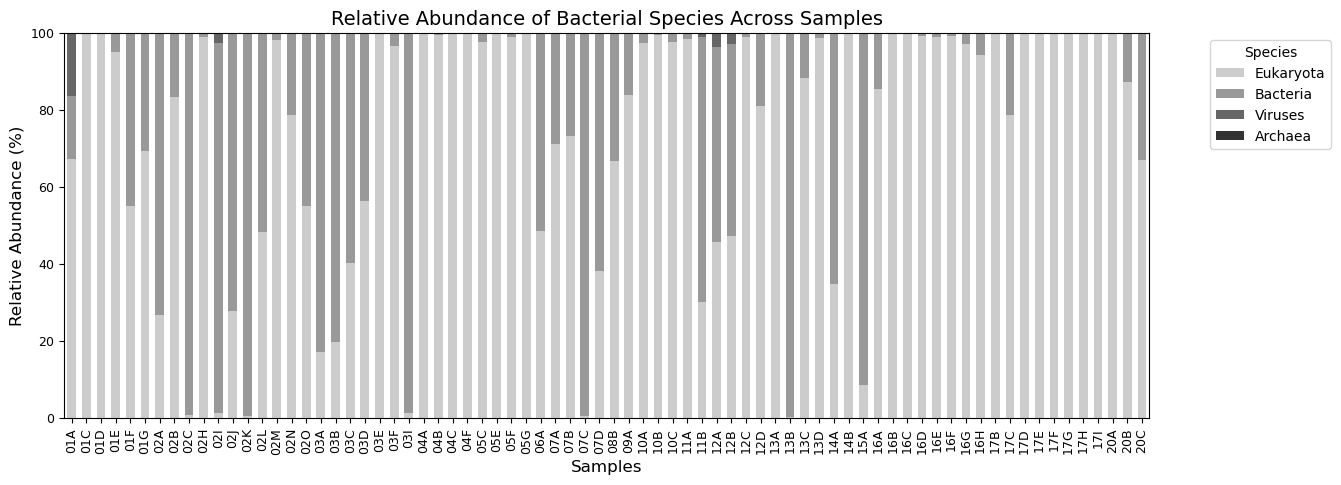

In [14]:
# Create a stacked bar plot for bacterial species abundance (abundance_df_s_bac)
fig, ax = plt.subplots(figsize=(14, 5))

# Create a modified dataframe with top species and an "Other" category
plot_df = abundance_df_d.copy()

plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.6,
    color=sns.color_palette("gray_r", n_colors=len(plot_df.columns) + 0)[0:],
    # somehow directly telling seaborn to use gray_r looks not as good.
    # colormap="gray_r",
    legend=True,
    fontsize=9,
)

# Customize the plot
ax.set_xlabel("Samples", fontsize=12)
ax.set_ylabel("Relative Abundance (%)", fontsize=12)
ax.set_title("Relative Abundance of Bacterial Species Across Samples", fontsize=14)
ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylim(0, 100)  # Set y-axis limit to 100%
ax.set_xlim(-0.5, len(plot_df.index) - 0.5)  # Adjust x-axis limits

# Create the legend first
ax.legend(title="Species", fontsize=9)

# Then move it
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.05, 1))

fig.savefig("./figs/relab_sb_domain.svg", bbox_inches='tight')

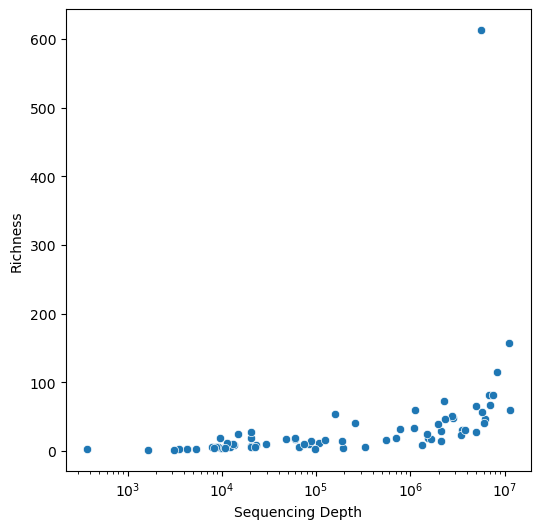

In [15]:
# compare alpha diversity (richness) against sequencing depth
fig, ax = plt.subplots(figsize=(6, 6))
richness = abundance_df_s_bac.astype(bool).sum(axis=1)
sns.scatterplot(
    data=pd.DataFrame(
        {
            "Richness": richness,
            "Sequencing Depth": read_count_df_s_bac.sum(axis=1),
        }
    ),
    x="Sequencing Depth",
    y="Richness",
    ax=ax,
)
ax.set_xscale("log")

### Without host

In [16]:
abundance_df, read_count_df, tax_df = parse_bracken_reports("./kraken")
index = abundance_df.index
# Rename samples to be more readable
index_new = index.map(rename_sample)
abundance_df.index = abundance_df.index.map(rename_sample)
read_count_df.index = read_count_df.index.map(rename_sample)
abundance_df = abundance_df.sort_index()
read_count_df = read_count_df.sort_index()

Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples
Duplicate taxon name: environmental samples


In [17]:
tax2level = {
    idx: tax_df.columns[np.where(~row.isnull())[0].max()]
    for idx, row in tax_df.iterrows()
}
abundance_df_s = abundance_df[[t for t in abundance_df.columns if tax2level[t] == "S"]]
abundance_df_d = abundance_df[[t for t in abundance_df.columns if tax2level[t] == "D"]]
read_count_df_s = read_count_df[
    [t for t in abundance_df.columns if tax2level[t] == "S"]
].astype(int)
read_count_df_d = read_count_df[
    [t for t in abundance_df.columns if tax2level[t] == "D"]
].astype(int)

abundance_df_s_bac = abundance_df_s[
    [t for t in abundance_df_s.columns if tax_df.loc[t, "D"] == "Bacteria"]
]
abundance_df_s_bac = abundance_df_s_bac.div(abundance_df_s_bac.sum(axis=1), axis=0)
read_count_df_s_bac = read_count_df[
    [
        t
        for t in abundance_df_s.columns
        if tax_df.loc[t, "D"] == "Bacteria" and tax2level[t] == "S"
    ]
].astype(int)

/tmp/ipykernel_375491/3496164170.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


[Text(0, 0, '01A'),
 Text(1, 0, '01C'),
 Text(2, 0, '01D'),
 Text(3, 0, '01E'),
 Text(4, 0, '01F'),
 Text(5, 0, '01G'),
 Text(6, 0, '02A'),
 Text(7, 0, '02B'),
 Text(8, 0, '02C'),
 Text(9, 0, '02H'),
 Text(10, 0, '02I'),
 Text(11, 0, '02J'),
 Text(12, 0, '02K'),
 Text(13, 0, '02L'),
 Text(14, 0, '02M'),
 Text(15, 0, '02N'),
 Text(16, 0, '02O'),
 Text(17, 0, '03A'),
 Text(18, 0, '03B'),
 Text(19, 0, '03C'),
 Text(20, 0, '03D'),
 Text(21, 0, '03E'),
 Text(22, 0, '03F'),
 Text(23, 0, '03I'),
 Text(24, 0, '04A'),
 Text(25, 0, '04B'),
 Text(26, 0, '04C'),
 Text(27, 0, '04F'),
 Text(28, 0, '05C'),
 Text(29, 0, '05E'),
 Text(30, 0, '05F'),
 Text(31, 0, '05G'),
 Text(32, 0, '06A'),
 Text(33, 0, '07A'),
 Text(34, 0, '07B'),
 Text(35, 0, '07C'),
 Text(36, 0, '07D'),
 Text(37, 0, '08B'),
 Text(38, 0, '09A'),
 Text(39, 0, '10A'),
 Text(40, 0, '10B'),
 Text(41, 0, '10C'),
 Text(42, 0, '11A'),
 Text(43, 0, '11B'),
 Text(44, 0, '12A'),
 Text(45, 0, '12B'),
 Text(46, 0, '12C'),
 Text(47, 0, '12D'),
 T

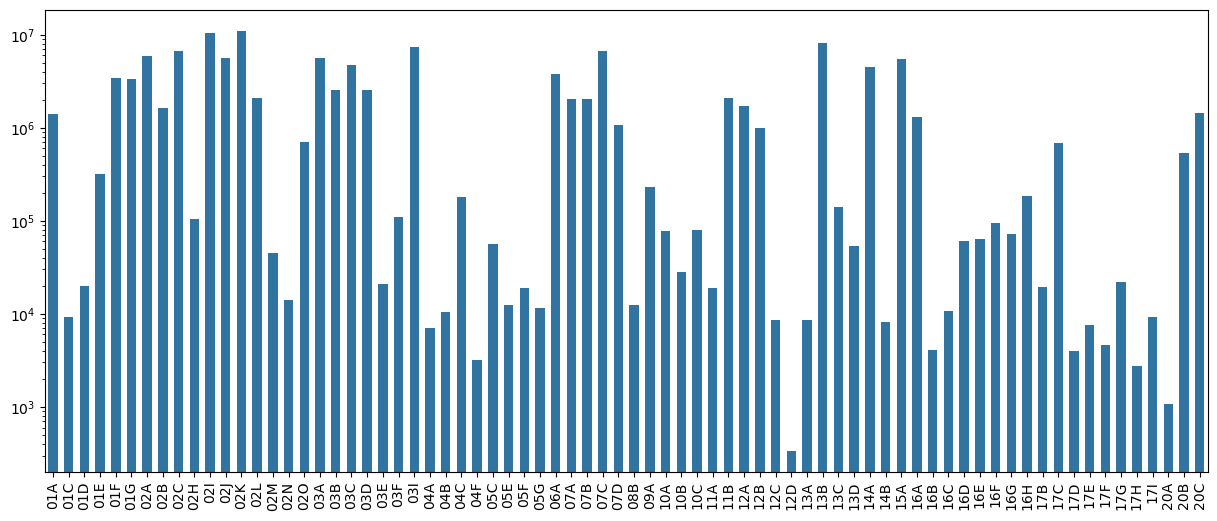

In [18]:
fig, ax= plt.subplots(figsize=(15, 6))
# read_count_df_s_bac.sum(axis=1).plot(kind="bar", logy=True, ax=ax)
sns.barplot(
    data=read_count_df_s_bac.sum(axis=1),
    ax=ax,
    width=0.6,
    # log_scale=(False, True),
    # ci=None,
)
ax.set_yscale("log")
# rotate x-axis labels by 90 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
# a horizontal line at 1e5
# ax.axhline(2e3, color="red", linestyle="--")

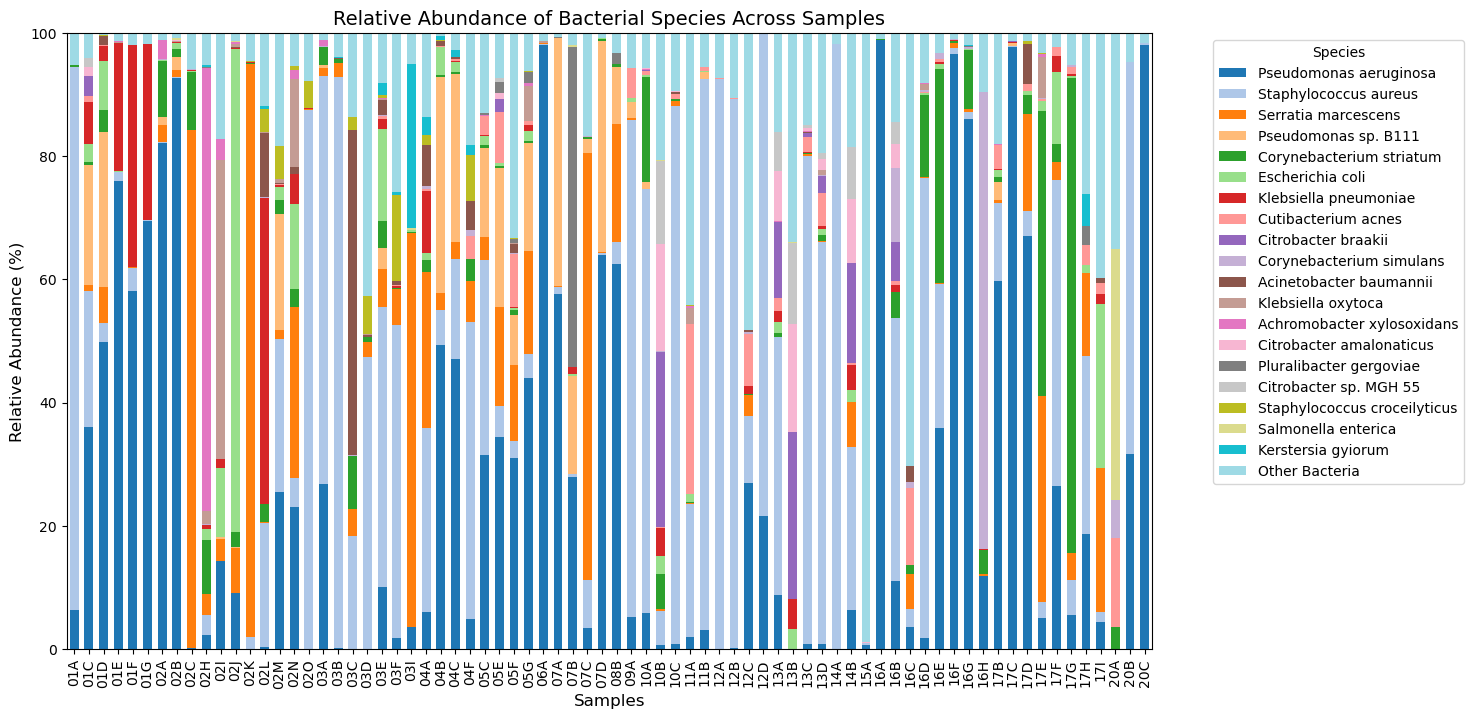

In [19]:
# Create a stacked bar plot for bacterial species abundance (abundance_df_s_bac)
fig, ax = plt.subplots(figsize=(14, 8))

# Getting the top bacteria species for better visualization and legend readability
# Select top N species by mean abundance across samples
n_top_species = 19  # Adjust this number as needed
top_species = (
    abundance_df_s_bac.mean()
    .sort_values(ascending=False)
    .head(n_top_species)
    .index.tolist()
)
other_species = [col for col in abundance_df_s_bac.columns if col not in top_species]

# Create a modified dataframe with top species and an "Other" category
plot_df = abundance_df_s_bac[top_species].copy()
plot_df["Other Bacteria"] = abundance_df_s_bac[other_species].sum(axis=1)

# Set up colors - use a colorful palette for bacteria
colors = sns.color_palette("tab20", n_top_species + 1)  # +1 for the "Other" category

# Create the stacked bar plot
bottom = np.zeros(len(plot_df))
for i, species in enumerate(plot_df.columns):
    ax.bar(
        plot_df.index,
        plot_df[species] * 100,  # Convert to percentage
        bottom=bottom,
        label=species,
        color=colors[i],
        width=0.6,
    )
    bottom += plot_df[species].to_numpy() * 100

# Customize the plot
ax.set_xlabel("Samples", fontsize=12)
ax.set_ylabel("Relative Abundance (%)", fontsize=12)
ax.set_title("Relative Abundance of Bacterial Species Across Samples", fontsize=14)
ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylim(0, 100)  # Set y-axis limit to 100%
ax.set_xlim(-0.5, len(plot_df.index) - 0.5)  # Adjust x-axis limits

# Create the legend first
ax.legend(title="Species", fontsize=9)

# Then move it
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.05, 1))

# # Add percentages for species with significant abundance
# threshold = (
#     5  # Show percentages for species that make up at least 5% of bacterial abundance
# )
# for i, sample in enumerate(plot_df.index):
#     y_pos = 0
#     for species in plot_df.columns:
#         height = plot_df.loc[sample, species] * 100
#         if height > threshold:
#             ax.text(
#                 i,
#                 y_pos + height / 2,
#                 f"{height:.1f}%",
#                 ha="center",
#                 va="center",
#                 fontsize=8,
#                 color="white",
#             )
#         y_pos += height
